
## INSURANCE CLAIM PROJECT

### Background:
Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, the attributes of customers can be crucial in making business decisions. Hence, knowing to explore and generate value out of such data can be an invaluable skill to have.
As a Data Scientist/Analyst in the Abuja Insurance company. The company wants to have a detailed understanding of the customer base for one of its Insurance Policy 'MediClaim'. The idea is to generate insights about the customers and answer a few key questions, by using the past dataset. The dataset 'abuja_Insurance' contains customers' details like age, sex, charges, etc.

### Objective:

>  Explore the dataset and extract insights using Exploratory Data Analysis.
- Prove(or disprove) that the medical claims made by the people who smoke are greater than those who don't?
- Prove (or disprove) with that the BMI of females is different from that of males.
- Does the smoking habit of customers depend on their region?
- Is the mean BMI of women with no children, one child, and two children the same? 



#### Data Dictionary –
- Age - This is an integer indicating the age of the primary beneficiary (excluding those above 64 years, since they are generally covered by the government).
- Sex - This is the policy holder's gender, either male or female.
- BMI - This is the body mass index (BMI), which provides a sense of how over or underweight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.
- Children - This is an integer indicating the number of children/dependents covered by the insurance plan.
- Smoker - This is yes or no depending on whether the insured regularly smokes tobacco.
- Region - This is the beneficiary's place of residence in the U.S., divided into four geographic regions - northeast, southeast, southwest, or northwest.
- Charges - Individual medical costs billed to health insurance


### importing necesary libraries

In [2]:
#import libraries
import numpy as np
import pandas as pd

In [5]:
# data importing and reading in of Data sets
insurance = pd.read_csv("abuja_Insurance.csv")
df = insurance.copy()

In [6]:
#assess the dataset's description
df.head()

,age,sex,bmi,children,smoker,region,charges
0,21,female,16.000,1,no,northeast,3167.45585
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# assess the dataset's description cont.
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
display(df.describe(include='all'))

Shape of dataset: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Statistical summary:


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.682687,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.145674,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,14.000000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.315000,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16639.912515


In [8]:
#assess the dataset for data duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# view duplicates if any
display(df[df.duplicated()])

Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
#assess the dataset for missing data
print("Missing values per column:", display(df.isnull().sum()))

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Missing values per column: None


In [10]:
# remove duplicates for cleaner analysis
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


### EXPLORATTORY DATA ANALYSIS

### Univariate Analysis

In [11]:
#importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

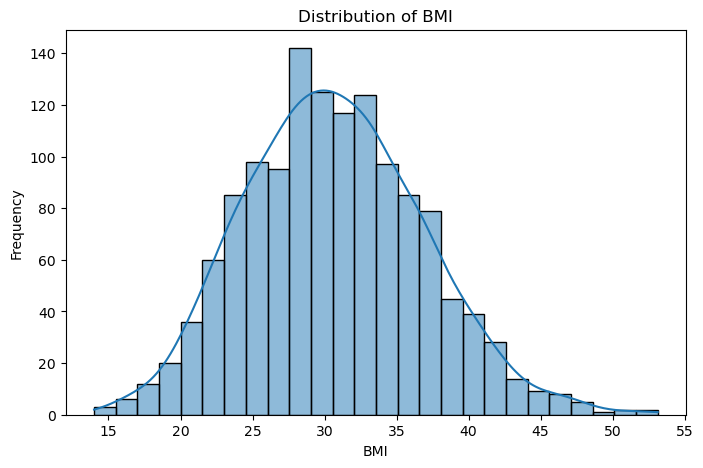

count    1337.000000
mean       30.682756
std         6.147973
min        14.000000
25%        26.315000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64
Skewness of BMI: 0.26677675635745873


In [12]:
#univariate analysis for the body mass index feature
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

print(df['bmi'].describe())
print("Skewness of BMI:", df['bmi'].skew())

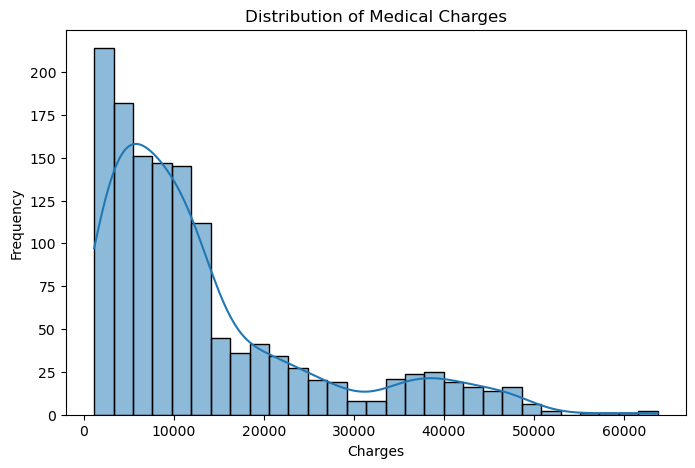

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64
Skewness of Charges: 1.515390910840348


In [13]:
#univariate analysis for the charges feature
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

print(df['charges'].describe())
print("Skewness of Charges:", df['charges'].skew())

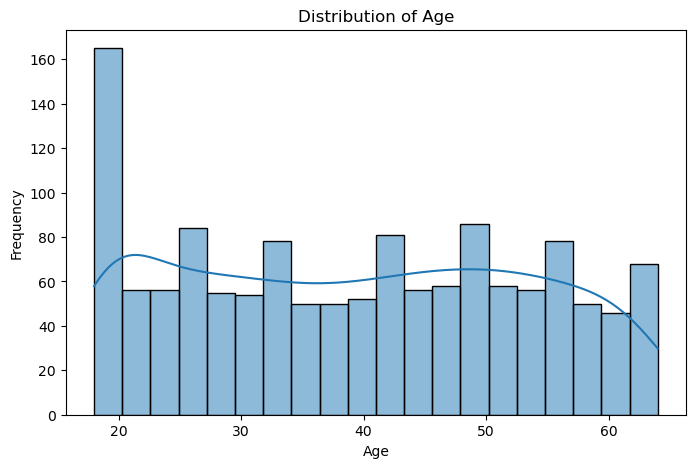

count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64
Skewness of Age: 0.05478077312699819


In [14]:
#univariate analysis for the age feature
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True, bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print(df['age'].describe())
print("Skewness of Age:", df['age'].skew())

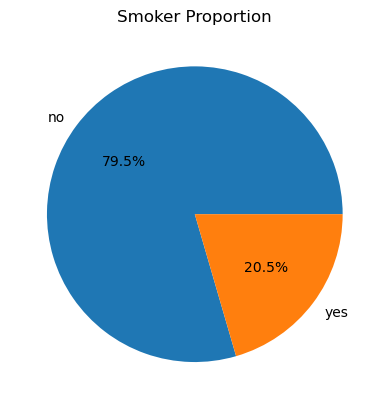

In [15]:
#univariate analysis of the smoker feature
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Smoker Proportion")
plt.ylabel("")
plt.show()

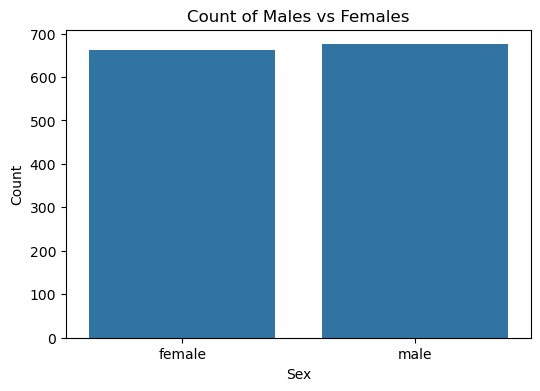

sex
male      675
female    662
Name: count, dtype: int64

sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64

In [16]:
#graphical visualization of the sex feature
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex')
plt.title("Count of Males vs Females")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# count of male and female
display(df['sex'].value_counts())
# show the percentage of male and female
display(df['sex'].value_counts(normalize=True) * 100)

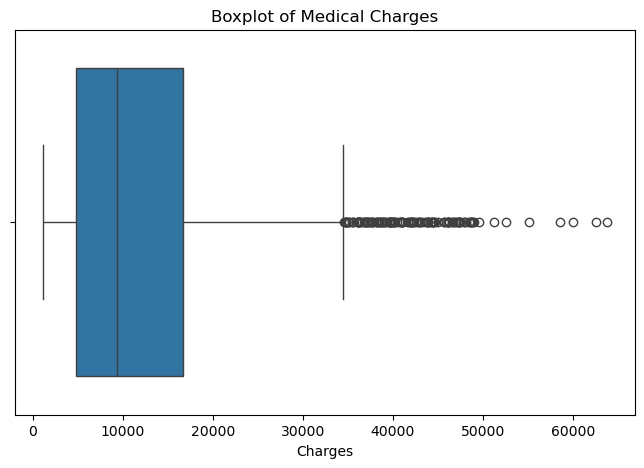

In [17]:
# graphical visualiation of the target label(charges feature)
plt.figure(figsize=(8,5))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Medical Charges")
plt.xlabel("Charges")
plt.show()

## Observations
- #### BMI
BMI is centered around 30.68, which is above the ideal BMI range of 18.5 to 24.9.
This suggests that many policyholders are overweight or obese.
The BMI distribution is close to symmetric with only slight skewness.
- #### CHARGES
Medical charges are strongly right-skewed.
Most customers have relatively low to moderate charges, while a smaller group has very high charges.
This indicates the presence of outliers/high-cost claimants.
- #### AGE
The ages range from 18 to 64 years.
The distribution is fairly spread across adult age groups.
The mean age is around 39 years.
- #### SMOKER
Non-smokers are the majority in the dataset.
Smokers form a much smaller proportion of the insured population.
- #### SEX
The dataset is nearly balanced between male and female customers.
- #### MEDICAL CHARGES
There are several high-value outliers in the charges variable.
These likely represent customers with very expensive medical claims.


### Bivariate Analysis

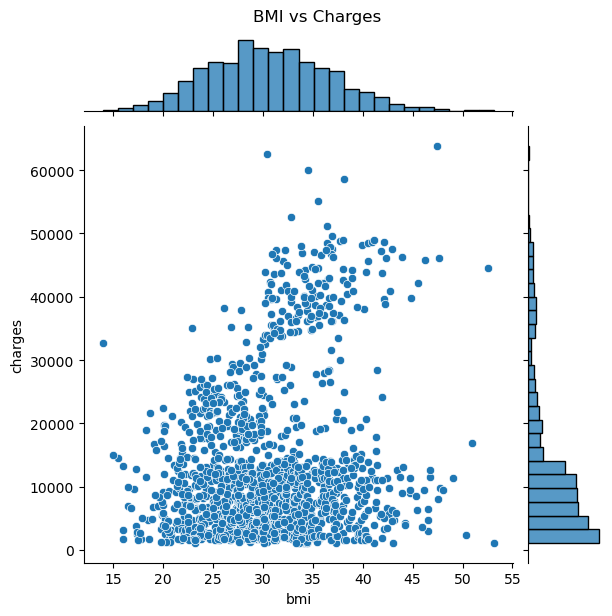

In [18]:
#jointplot exploring the relationship between the bmi vs charges features
sns.jointplot(data=df, x='bmi', y='charges', kind='scatter', height=6)
plt.suptitle("BMI vs Charges", y=1.02)
plt.show()

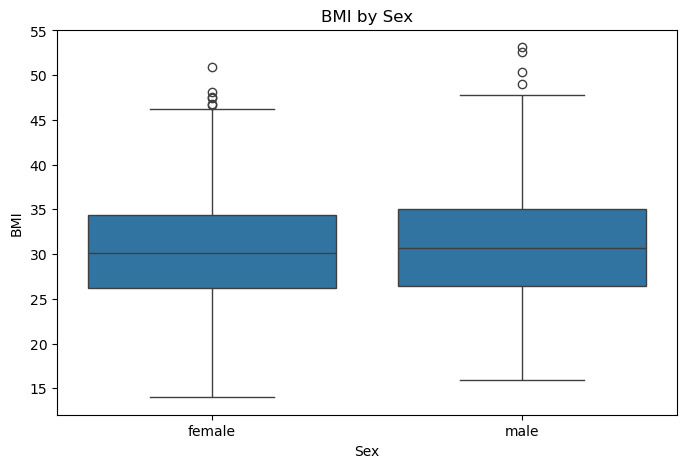

In [19]:
#exploring the distributions and the relationships between the bmi vs the sex/gender feature
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sex', y='bmi')
plt.title("BMI by Sex")
plt.xlabel("Sex")
plt.ylabel("BMI")
plt.show()

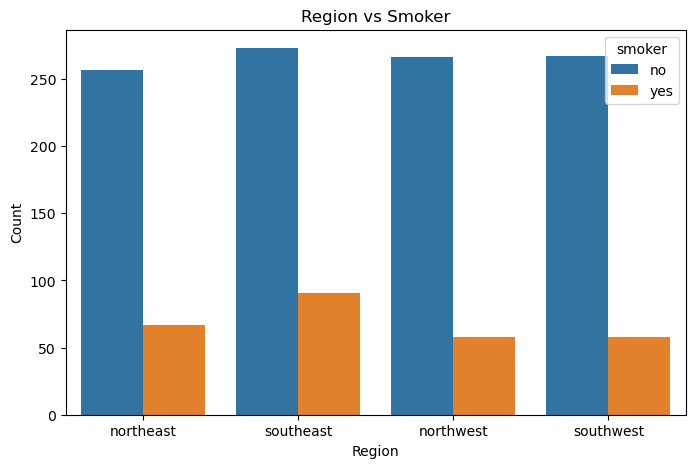

smoker,no,yes
region,,
northeast,257,67
northwest,266,58
southeast,273,91
southwest,267,58


In [20]:
#bivariate analysis of the region vs smoker features
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='region', hue='smoker')
plt.title("Region vs Smoker")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

region_smoker_table = pd.crosstab(df['region'], df['smoker'])
display(region_smoker_table)

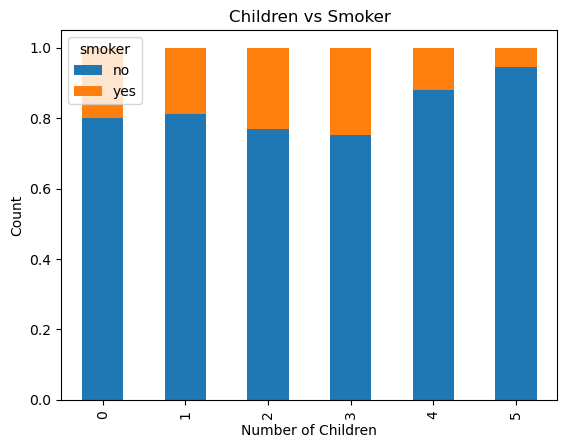

In [21]:
#exploring the relationship between the number of children feature and the smoker feature 
child_smoker = pd.crosstab(df['children'], df['smoker'], normalize='index')

child_smoker.plot(kind='bar', stacked=True)
plt.title("Children vs Smoker")
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.show()

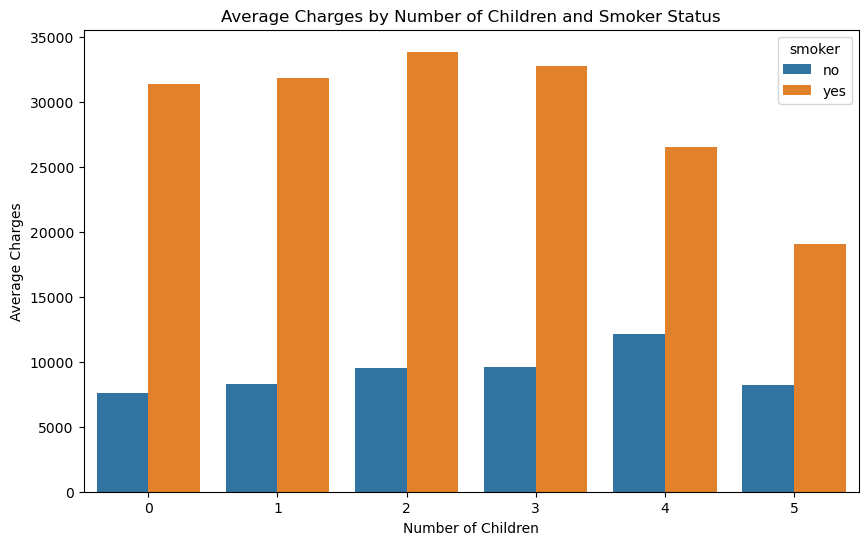

smoker,no,yes
children,,
0,7624.833139,31341.363954
1,8303.109350,31822.654334
2,9493.093674,33844.235755
3,9614.519391,32724.915268
4,12121.344408,26532.276933
5,8183.845556,19023.260000


In [22]:
#bivariate analysis of the number of children feature Vs the medical claim charges feature Vs the smoker feature
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='children', y='charges', hue='smoker', estimator=np.mean, errorbar=None)
plt.title("Average Charges by Number of Children and Smoker Status")
plt.xlabel("Number of Children")
plt.ylabel("Average Charges")
plt.show()


display(df.groupby(['children', 'smoker'])['charges'].mean().unstack())

## Observation
- #### BMI VS CHARGES
There is a positive relationship between BMI and charges, but it is not very strong for the full dataset.
Some of the highest charges occur among customers with moderate to high BMI values.
The spread in charges becomes much larger as BMI increases.
- #### BMI VS SEX
Male and female BMI distributions are very similar.
Their medians and spread are close, suggesting no large visible gender difference in BMI.
- #### REGION VS SMOKER
Every region contains both smokers and non-smokers.
Southeast appears to have a relatively higher number of smokers than some other regions, but the difference is not very large.
- #### CHILDREN VS SMOKER
Non-smokers outnumber smokers at every children count level.
Most customers have 0, 1, or 2 children.
- #### CHILDREN VS CHARGES VS SMOKER
Smokers have much higher average charges than non-smokers across nearly all child categories.
Smoking status appears to influence charges far more strongly than number of children.

### Multivariate Analaysis

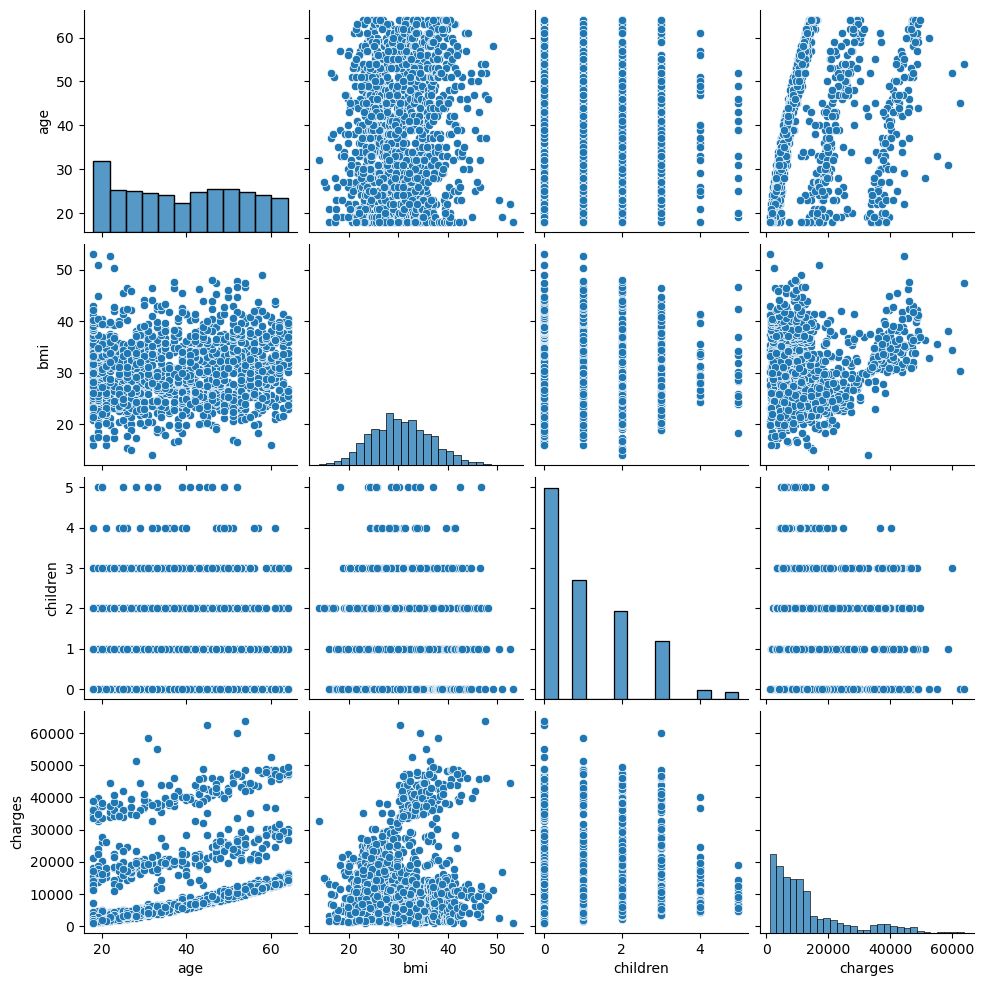

In [23]:
#use a pairplot to explore the relationship between the nummerical features in the dataset
sns.pairplot(df[['age', 'bmi', 'children', 'charges']], diag_kind='hist')
plt.show()

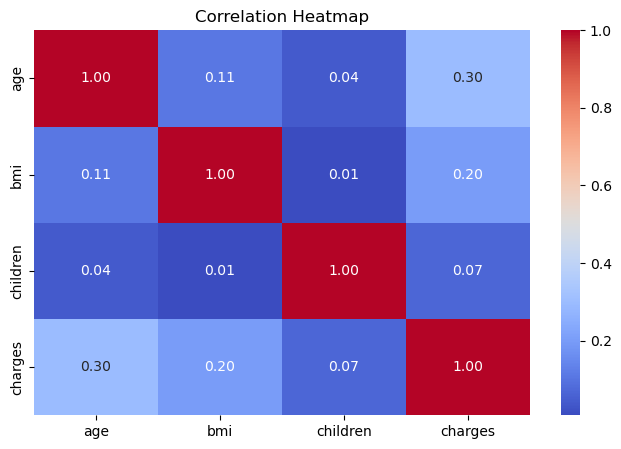

In [25]:
# heatmeap to see the correlation between features. 
plt.figure(figsize=(8,5))
corr = df[['age', 'bmi', 'children', 'charges']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# display(corr)

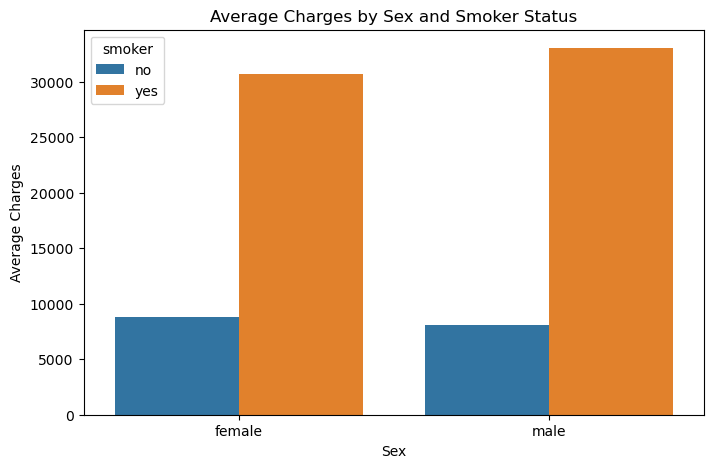

smoker,no,yes
sex,,
female,8762.297300,30678.996276
male,8099.700161,33042.005975


In [27]:
#exploring the relationship between the sex vs smoker vs charges features
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='sex', y='charges', hue='smoker', estimator=np.mean, errorbar=None)
plt.title("Average Charges by Sex and Smoker Status")
plt.xlabel("Sex")
plt.ylabel("Average Charges")
plt.show()

display(df.groupby(['sex', 'smoker'])['charges'].mean().unstack())

## Observations
- #### PAIRPLOT
Charges rise noticeably with age.
Charges also tend to be higher for some customers with higher BMI.
Children has a weaker relationship with charges compared to age and BMI.
- #### HEATMAP
Age has a moderate positive correlation with charges.
BMI has a weak positive correlation with charges.
Children has a weak positive correlation with charges.
Overall, numerical variables alone do not fully explain charges, suggesting that categorical factors such as smoking are very important.
- #### SEX VS SMOKER VS CHARGES
For both males and females, smokers have far higher average charges than non-smokers.
Within each smoking group, differences between male and female charges are relatively small compared with the smoking effect.
Smoking is the strongest visible driver of medical charges in this dataset.

